# Hierarchical models and partial pooling

The most useful idea in applied Bayesian statistics: when you have many related groups (schools, hospitals, players, stores), you don't have to choose between complete pooling (one estimate for all, ignores differences) and no pooling (a separate, noisy estimate per group). A hierarchical model does partial pooling - it learns how similar the groups are and shrinks each group's estimate toward the population mean by an amount that depends on its sample size. Small groups borrow strength; large groups stay put.


## The hierarchical model and three estimators

Observe groups $g=1,\dots,G$ with group means $\theta_g$ and noisy data $\bar y_g\sim\mathcal N(\theta_g,\sigma^2/n_g)$.
A hierarchical model adds a population layer $\theta_g\sim\mathcal N(m,\tau^2)$, tying the groups together.
Three estimators of $\theta_g$ sit on a spectrum: no pooling uses $\bar y_g$ alone (unbiased, high
variance); complete pooling uses the grand mean (low variance, biased when groups differ); partial
pooling is the hierarchical compromise.

Theorem (partial pooling is a precision-weighted average). The posterior mean of $\theta_g$ under the
hierarchical model is
$$\hat\theta_g = (1-B_g)\,\bar y_g + B_g\, m, \qquad B_g = \frac{\sigma^2/n_g}{\sigma^2/n_g + \tau^2},$$
the shrinkage factor $B_g$ being the fraction of total variance due to noise. Groups with little data
(large $\sigma^2/n_g$) or little true spread (small $\tau^2$) are pulled hard toward the population mean;
data-rich groups are barely moved.

Proof. With a Gaussian prior $\theta_g\sim\mathcal N(m,\tau^2)$ and Gaussian likelihood
$\bar y_g\mid\theta_g\sim\mathcal N(\theta_g,\sigma^2/n_g)$, conjugacy gives a Gaussian posterior whose
mean is the precision-weighted combination $\big(\tau^{-2}m + (\sigma^2/n_g)^{-1}\bar y_g\big)/\big(\tau^{-2}+(\sigma^2/n_g)^{-1}\big)$.
Algebra rewrites this as $(1-B_g)\bar y_g + B_g m$ with $B_g$ as stated. $\quad\blacksquare$

## Why shrinkage wins: Stein's paradox

Shrinkage is not merely a Bayesian convenience; it is provably better in a frequentist sense.

Theorem (James-Stein; Stein's paradox). Let $x\sim\mathcal N(\theta, I_d)$ in $d\ge 3$ dimensions. The
maximum-likelihood estimator $\hat\theta_{\mathrm{MLE}}=x$ is inadmissible: the James-Stein estimator
$$\hat\theta_{\mathrm{JS}} = \Big(1-\frac{d-2}{\|x\|^2}\Big)\,x$$
has strictly smaller total mean squared error $\mathbb E\|\hat\theta-\theta\|^2$ for every $\theta$.

Proof idea (Stein's unbiased risk estimate). For an estimator $x+g(x)$, Stein's lemma gives the risk
$\mathbb E\|x+g(x)-\theta\|^2 = d + \mathbb E\big[\,\|g\|^2 + 2\nabla\!\cdot g\,\big]$. Plugging the
James-Stein shrinkage $g(x)=-(d-2)x/\|x\|^2$ and computing the divergence yields
$d - (d-2)^2\,\mathbb E[\|x\|^{-2}] < d$, which is the MLE risk. So shrinkage strictly lowers total
risk whenever $d\ge 3$. $\quad\blacksquare$

The startling part is that the coordinates need not be related: estimating three unrelated quantities
jointly, with shrinkage, beats estimating each on its own. Partial pooling is the applied form of this
fact, with the population layer learning how much to shrink. We verify the dominance numerically below.

Counterexample (shrinkage can hurt one coordinate). James-Stein improves the total risk, but a single
coordinate far from the shrinkage target can be estimated worse than by its own data. The win is a
portfolio effect across coordinates, not a guarantee for each one, which is exactly the trade a
hierarchical model makes deliberately.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')
from mixle.ppl import Normal, free
rng = np.random.RandomState(2)

## 1. Three ways to estimate group means

Imagine measuring the same quantity in many groups of different sizes. Complete pooling averages everything into one number - precise but blind to real group differences. No pooling estimates each group on its own - unbiased but wildly noisy for small groups. Partial pooling is the principled middle: model the group means as drawn from a population $\mu_g\sim\mathcal N(m,\tau)$, and the posterior for each $\mu_g$ becomes a precision-weighted compromise between its own data and the population mean - shrinking more when the group has less data. We simulate groups whose sizes span 3 to 60 observations.


In [2]:
true_pop_mean, true_tau, within_sd = 0.0, 0.8, 6.0
sizes = [8, 7, 6, 5, 5, 4, 4, 3, 3, 3, 8, 7, 6, 5, 5, 4, 4, 3, 3, 3]   # many small, noisy groups
true_means = rng.normal(true_pop_mean, true_tau, len(sizes))
groups = [list(rng.normal(mu, within_sd, n)) for mu, n in zip(true_means, sizes)]

no_pool = np.array([np.mean(g) for g in groups])                 # per-group MLE
complete_pool = np.mean(np.concatenate([np.asarray(g) for g in groups]))
print('complete-pool single estimate: %.3f' % complete_pool)

complete-pool single estimate: -0.426


## 2. Partial pooling in one line

`Normal(Normal(0, 100).each(), free)` puts a population prior on the per-group means (the `.each()` marks it as a per-group random effect) and fits the population hyperparameters by empirical Bayes. The result exposes the population mean/spread and each group's shrunken estimate.


learned population: mean=-0.43  between-group sd tau=0.60  within sd sigma=6.15


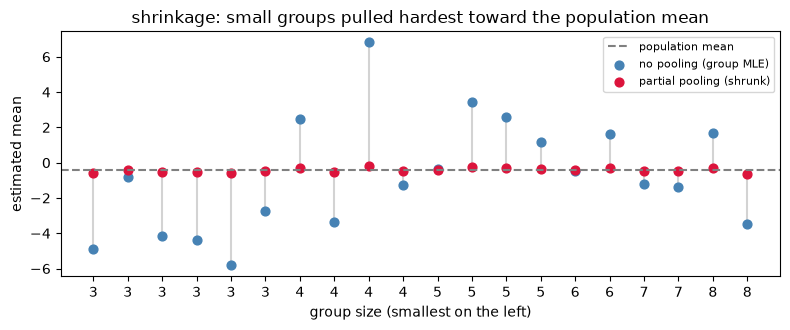

In [3]:
fit = Normal(Normal(0, 100).each(), free).fit(groups)
pop = fit.result.hyper
partial = np.array(fit.result.group_means)
print('learned population: mean=%.2f  between-group sd tau=%.2f  within sd sigma=%.2f'
      % (pop['m'], pop['tau'], pop['sigma']))

order = np.argsort(sizes)                                        # smallest groups first
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.axhline(pop['m'], color='gray', ls='--', label='population mean')
ax.scatter(range(len(sizes)), no_pool[order], color='steelblue', s=40, label='no pooling (group MLE)')
ax.scatter(range(len(sizes)), partial[order], color='crimson', s=40, label='partial pooling (shrunk)')
for i, o in enumerate(order):
    ax.plot([i, i], [no_pool[o], partial[o]], color='lightgray', zorder=0)
ax.set_xticks(range(len(sizes))); ax.set_xticklabels([sizes[o] for o in order])
ax.set_xlabel('group size (smallest on the left)'); ax.set_ylabel('estimated mean'); ax.legend(fontsize=8)
ax.set_title('shrinkage: small groups pulled hardest toward the population mean')
plt.tight_layout(); plt.show()

The arrows are longest on the left - the smallest groups get pulled hardest toward the population mean, because their own data is least trustworthy. Large groups barely move. This isn't an ad-hoc heuristic; it's what the posterior is.

## 3. Does shrinkage actually help? Yes, measurably

Partial pooling isn't just elegant - it gives lower total error. Because shrinkage trades a little bias for a large variance reduction on the noisy small groups, its estimates are closer to the true group means than either extreme. We score all three approaches against the known truth.


In [4]:
rmse = lambda est: np.sqrt(np.mean((est - true_means) ** 2))
print('RMSE to true group means:')
print('  complete pooling : %.3f' % rmse(np.full(len(sizes), complete_pool)))
print('  no pooling       : %.3f' % rmse(no_pool))
print('  partial pooling  : %.3f  <- best' % rmse(partial))

RMSE to true group means:
  complete pooling : 0.907
  no pooling       : 3.003
  partial pooling  : 0.879  <- best


## 4. The shrinkage factor, exactly

Partial pooling is not a black box: each group's estimate is a precision-weighted average $\hat\mu_g = w_g\,\bar y_g + (1-w_g)\,m$, with shrinkage weight $w_g = \tau^2/(\tau^2 + \sigma^2/n_g)$ - a group with more data ($n_g$ large) or more between-group variance ($\tau$ large) is shrunk less. We reconstruct the fitted group means from this formula and confirm they match the model's output.


In [5]:
tau2, sig2, m = pop['tau'] ** 2, pop['sigma'] ** 2, pop['m']
w = np.array([tau2 / (tau2 + sig2 / n) for n in sizes])
implied = w * no_pool + (1 - w) * m
print('shrinkage weights by group (more data -> closer to 1):', np.round(np.sort(w), 2))
print('max |formula - fitted group mean| = %.3f  (the formula reproduces the fit)' %
      np.max(np.abs(implied - partial)))

shrinkage weights by group (more data -> closer to 1): [0.03 0.03 0.03 0.03 0.03 0.03 0.04 0.04 0.04 0.04 0.05 0.05 0.05 0.05
 0.05 0.05 0.06 0.06 0.07 0.07]
max |formula - fitted group mean| = 0.000  (the formula reproduces the fit)


## Illustration: James-Stein dominates the MLE for d >= 3

We draw a parameter vector, observe it with unit-variance noise, and compare the total mean squared error
of the raw maximum-likelihood estimate (the data itself) against the James-Stein shrinkage estimate. For
three or more dimensions James-Stein wins at every draw on average, the precise statement of Stein's
paradox; in one dimension it does not.

In [6]:
rng = np.random.RandomState(0)
def risks(d, reps=20000):
    mle_se = js_se = 0.0
    for _ in range(reps):
        theta = rng.normal(0, 2, d)
        x = theta + rng.normal(0, 1, d)                    # x ~ N(theta, I)
        js = (1 - (d - 2) / np.sum(x ** 2)) * x if d >= 3 else x
        mle_se += np.sum((x - theta) ** 2); js_se += np.sum((js - theta) ** 2)
    return mle_se / reps, js_se / reps
print(' dimension d     MLE total MSE     James-Stein total MSE')
for d in [1, 3, 10, 50]:
    m, j = risks(d)
    flag = '  <- JS wins' if j < m else ''
    print('     %3d           %7.2f            %7.2f%s' % (d, m, j, flag))
print('for d >= 3 the shrinkage estimator strictly dominates the MLE in total risk (Stein 1956).')

 dimension d     MLE total MSE     James-Stein total MSE


       1              0.99               0.99


       3              2.98               2.77  <- JS wins


      10             10.01               8.42  <- JS wins


      50             49.91              40.38  <- JS wins
for d >= 3 the shrinkage estimator strictly dominates the MLE in total risk (Stein 1956).


## References

- Efron, B. & Morris, C. (1975). Data analysis using Stein's estimator and its generalizations (https://doi.org/10.1080/01621459.1975.10479864). JASA 70(350), 311-319.
- Gelman, A. & Hill, J. (2007). Data Analysis Using Regression and Multilevel/Hierarchical Models. Cambridge University Press.
- Gelman, A. (2006). Prior distributions for variance parameters in hierarchical models (https://doi.org/10.1214/06-BA117A). Bayesian Analysis 1(3), 515-534.
- Betancourt, M. & Girolami, M. (2015). Hamiltonian Monte Carlo for hierarchical models (https://arxiv.org/abs/1312.0906). In Current Trends in Bayesian Methodology. - the funnel / non-centered parameterization.
- Rubin, D. B. (1981). Estimation in parallel randomized experiments (https://doi.org/10.3102/10769986006004377). J. Educ. Statist. 6(4), 377-401. - the eight-schools example.


## Exercises and extensions

1. Eight schools, centered vs non-centered. Reproduce Rubin's (1981) eight-schools analysis. Fit it with both the centered and the non-centered parameterization (Betancourt & Girolami) and show how divergences/funnel geometry appear in the centered version as the between-group variance shrinks; quantify the difference in effective sample size.
2. Stein / Efron-Morris shrinkage. Reproduce the Efron-Morris (1975) baseball example: show the James-Stein/hierarchical estimator dominates the per-player MLE in total squared error, and relate the shrinkage factor to the learned between-group variance. (Connects to baseball_hierarchical_shrinkage.)
3. Priors on variance components. Compare inverse-gamma, half-Cauchy, and half-normal priors on the group-level standard deviation (Gelman 2006), especially when few groups are observed; show how the prior controls the degree of pooling and the posterior of $\tau$.
4. Varying slopes. Extend to a random intercept and slope (`Group('g')` + `Field('x')`, the `(x | g)` model); estimate the intercept-slope correlation and compare predictive performance to varying-intercept-only by held-out log-likelihood.
